In [76]:
from dotenv import load_dotenv

import os
import numpy as np
import cv2
import matplotlib.pyplot as plt
import dlib

from pathlib import Path

from tqdm import tqdm

from typing import List

In [91]:
class PathManager:
    """환경 및 모듈 간 규격 클래스"""
    """상황에 맞게 경로와 규격을 수정 후 사용할 것"""
    
    def __init__(self, default_size: int):
        """dotenv 위치 찾기 + 로드"""
        self.root_path = self._find_root()
        self.dotenv_path = self.root_path / ".env" # 또는 self.dotenv_path = self.root_path / ".env"
        load_dotenv(self.dotenv_path)

        """이미지와 모델 디렉토리 인식"""
        self._images_dir = self.root_path / "Computer_Vision/CV01/data/images"
        self._models_dir = self.root_path / "Computer_Vision/models"
        self.default_size = default_size

    def _find_root(self, marker: str=".env") -> Path:
        """프로젝트 최상단 경로를 찾는 함수"""
        """.env를 마커로 사용"""
        current_cwd = Path().cwd().resolve()
        for parent in current_cwd.parents:
            if (parent / marker).exists():
                return parent

    def get_image_path(self, image_name: str) -> Path:
        """이미지 주소 획득"""
        return self._images_dir / image_name
        
    def get_model_path(self, model_name: str) -> Path:
        """모델 주소 획득"""
        return self._models_dir / model_name



In [106]:
class BaseModel:
    def __init__(self, model_path):
        self.model_path = model_path
        self.list_landmarks = []
        self.list_points = []


class ShapePredictor(BaseModel):
    
    def __init__(self, model_path):
        super().__init__(model_path)
        self.landmark_predictor = dlib.shape_predictor(str(self.model_path))

    def get_landmarks(self, image_rgb, dlib_rects):
        for dlib_rect in dlib_rects:
            points = self.landmark_predictor(image_rgb, dlib_rect)
            self.list_points = list(map(lambda p: (p.x, p.y), points.parts()))
            self.list_landmarks.append(self.list_points)
        print(len(self.list_landmarks))

    def draw_landmarks(self, image_rgb):
        for landmark in self.list_landmarks:
            for point in self.list_points:
                cv2.circle(image_rgb, point, 2, (255, 255, 60), -1)

        plt.imshow(image_rgb)        
        plt.show()



class ImageLoader:
    """이미지 로더: 경로 문제 생길 시 Config클래스 확인"""

    def __init__(self, image_path):
        self.img_bgr = cv2.imread(image_path, -1)
        self.img_bgr_copy = self.img_bgr.copy()
        self.img_rgb = cv2.cvtColor(self.img_bgr, cv2.COLOR_BGR2RGB)
        self.img_rgb_copy = self.img_rgb.copy()
    
    def show_image(self):
        plt.imshow(self.img_rgb)
        plt.show()
        return self.img_rgb


In [107]:
class FaceLoader(ImageLoader):
    def __init__(self, image_path):
        super().__init__(image_path)
        self.detector_hog = dlib.get_frontal_face_detector()
        self.dlib_rects = None
        self.boxes = []

    def get_box(self) -> List[dlib.rectangle]:
        self.dlib_rects = self.detector_hog(self.img_rgb, 1)
        return self.dlib_rects

    def draw_box(self):
        for dlib_rect in self.dlib_rects:
            left = dlib_rect.left()
            top = dlib_rect.top()
            right = dlib_rect.right()
            bottom = dlib_rect.bottom()

            cv2.rectangle(self.img_rgb, (left, top), (right, bottom), (60, 255, 60), 2, lineType=cv2.LINE_8)
            self.boxes.append([left, top, right, bottom])
            super().show_image()
            print(f"찾은 얼굴 개수: {len(self.boxes)}")

            

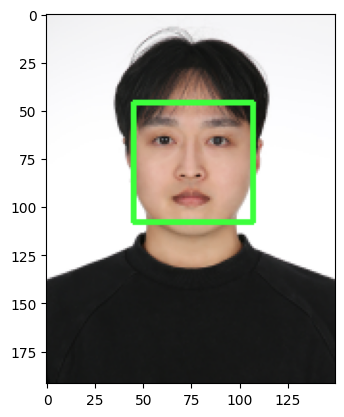

찾은 얼굴 개수: 1
1


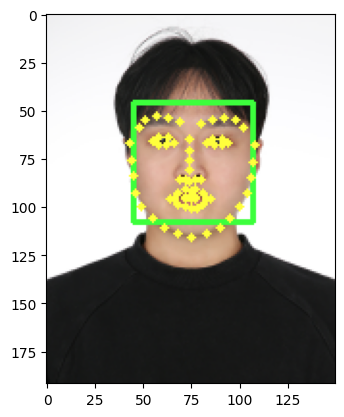

In [109]:
def run():
    path_manager = PathManager(63)
    face_path = path_manager.get_image_path("me.png")
    model_path = path_manager.get_model_path("shape_predictor_68_face_landmarks.dat")

    face_loader = FaceLoader(face_path)    
    face_loader.get_box()
    face_loader.draw_box()

    shape_predictor = ShapePredictor(model_path)
    shape_predictor.get_landmarks(face_loader.img_rgb, face_loader.dlib_rects)
    shape_predictor.draw_landmarks(face_loader.img_rgb)
    
run()